In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import entropy

In [2]:
df = pd.read_csv("dataset_unbalanced_final.csv")

print(df.shape)

df.head()

(11741, 8)


,Flow Duration,Flow Bytes/s,Flow Packets/s,Total Fwd Packets,SYN Flag Count,ACK Flag Count,Init_Win_bytes_forward,Label
0,3.361133,176.726129,2.677669,9,0,9,53248,ATTACK
1,2.948665,11836.542408,36.287606,107,9,98,65535,NORMAL
2,4.993487,5244.431771,70.091306,350,0,350,2047,NORMAL
3,0.096794,151889.378419,72.318436,7,1,7,65535,NORMAL
4,4.819635,10759.735082,3.942207,19,0,19,16,NORMAL


In [3]:
print("="*50)
print("INFO DATASET")
print("="*50)

df.info()

print()

print("="*50)
print("MISSING VALUE")
print("="*50)

print(df.isnull().sum())

print()

print("="*50)
print("DUPLICATE")
print("="*50)

print(df.duplicated().sum())

INFO DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11741 entries, 0 to 11740
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Flow Duration           11741 non-null  float64
 1   Flow Bytes/s            11741 non-null  float64
 2   Flow Packets/s          11741 non-null  float64
 3   Total Fwd Packets       11741 non-null  int64  
 4   SYN Flag Count          11741 non-null  int64  
 5   ACK Flag Count          11741 non-null  int64  
 6   Init_Win_bytes_forward  11741 non-null  int64  
 7   Label                   11741 non-null  object 
dtypes: float64(3), int64(4), object(1)
memory usage: 733.9+ KB

MISSING VALUE
Flow Duration             0
Flow Bytes/s              0
Flow Packets/s            0
Total Fwd Packets         0
SYN Flag Count            0
ACK Flag Count            0
Init_Win_bytes_forward    0
Label                     0
dtype: int64

DUPLICATE
0


In [4]:
print(df["Label"].value_counts())

print()

print(df["Label"].value_counts(normalize=True)*100)

Label
NORMAL    6436
ATTACK    5305
Name: count, dtype: int64

Label
NORMAL    54.816455
ATTACK    45.183545
Name: proportion, dtype: float64


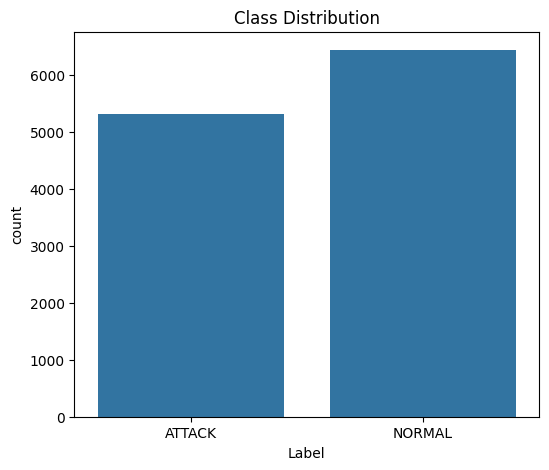

In [5]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="Label"
)

plt.title("Class Distribution")

plt.show()

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Flow Duration,11741.0,2.569840,1.858809,0.005885,0.373866,3.036306,4.408259,4.998009e+00
Flow Bytes/s,11741.0,24319.089837,90630.400199,36.065168,261.988933,3956.757917,20347.984782,5.178161e+06
Flow Packets/s,11741.0,28.258198,50.167460,0.614685,3.407093,6.878265,34.386024,5.097805e+02
Total Fwd Packets,11741.0,32.048292,79.569996,3.000000,6.000000,11.000000,21.000000,7.830000e+02
SYN Flag Count,11741.0,8.707435,62.738475,0.000000,0.000000,0.000000,1.000000,7.830000e+02
ACK Flag Count,11741.0,23.738523,51.406652,0.000000,5.000000,11.000000,20.000000,6.960000e+02
Init_Win_bytes_forward,11741.0,32775.580956,29764.991334,0.000000,255.000000,53248.000000,65535.000000,6.553500e+04


In [7]:
df.median(numeric_only=True)

Flow Duration                 3.036306
Flow Bytes/s               3956.757917
Flow Packets/s                6.878265
Total Fwd Packets            11.000000
SYN Flag Count                0.000000
ACK Flag Count               11.000000
Init_Win_bytes_forward    53248.000000
dtype: float64

In [8]:
features = df.columns.drop("Label")

df[features].var().sort_values()

Flow Duration             3.455170e+00
Flow Packets/s            2.516774e+03
ACK Flag Count            2.642644e+03
SYN Flag Count            3.936116e+03
Total Fwd Packets         6.331384e+03
Init_Win_bytes_forward    8.859547e+08
Flow Bytes/s              8.213869e+09
dtype: float64

In [9]:
df[features].std().sort_values()

Flow Duration                 1.858809
Flow Packets/s               50.167460
ACK Flag Count               51.406652
SYN Flag Count               62.738475
Total Fwd Packets            79.569996
Init_Win_bytes_forward    29764.991334
Flow Bytes/s              90630.400199
dtype: float64

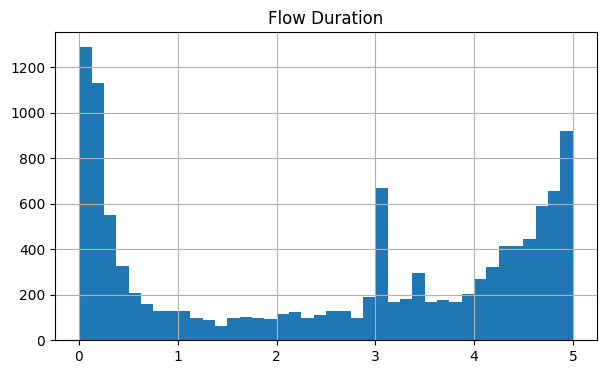

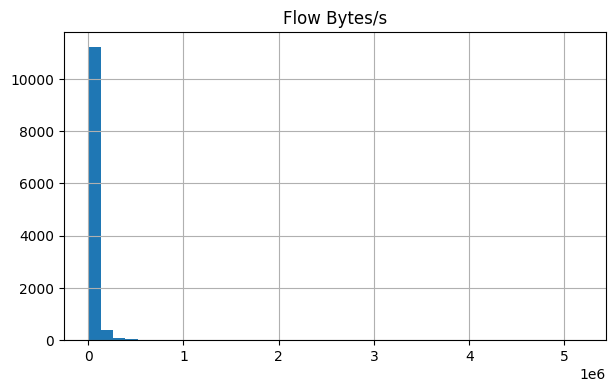

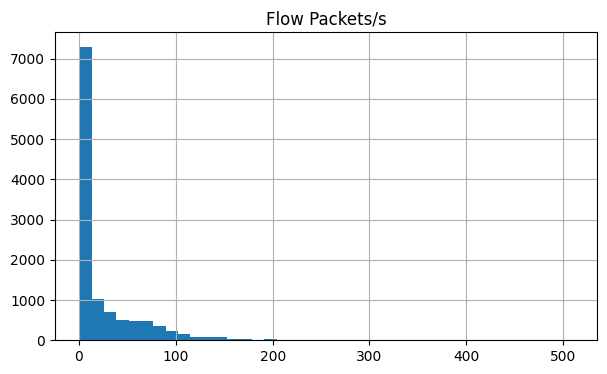

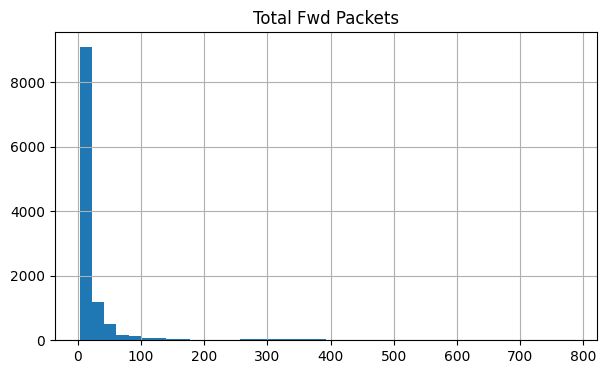

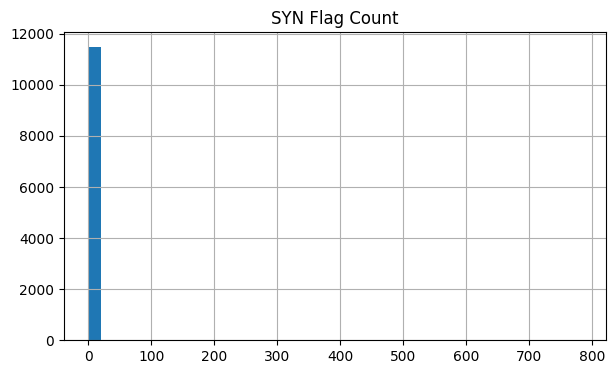

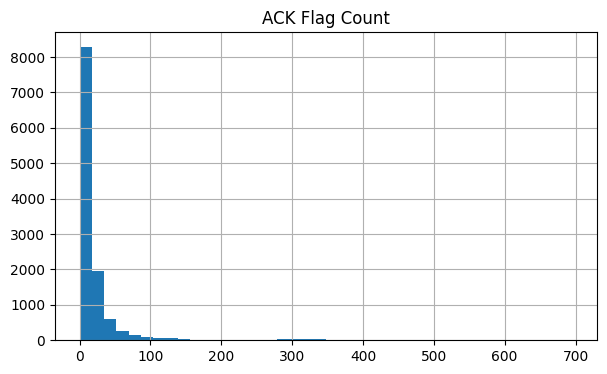

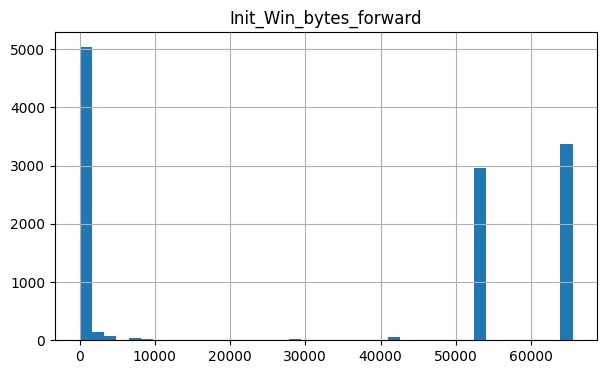

In [10]:
features = df.columns.drop("Label")

for col in features:

    plt.figure(figsize=(7,4))

    plt.hist(
        df[col],
        bins=40
    )

    plt.title(col)

    plt.grid(True)

    plt.show()

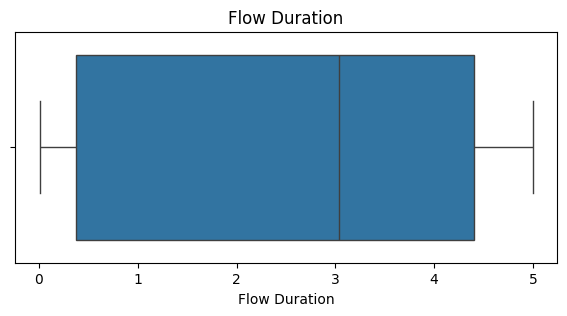

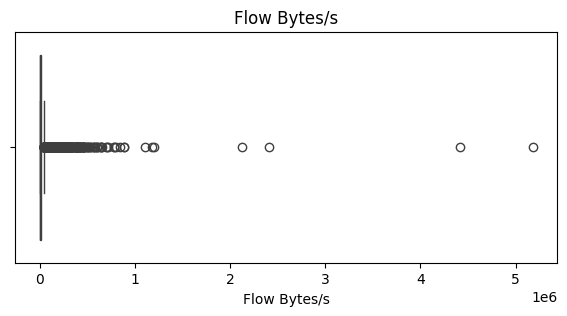

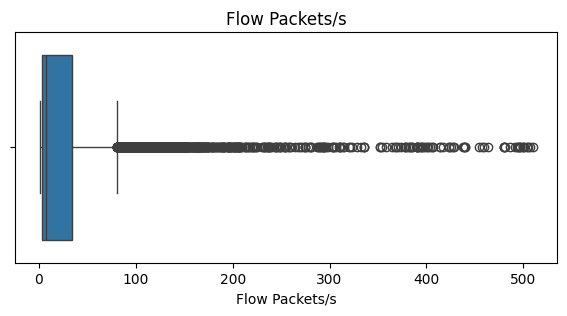

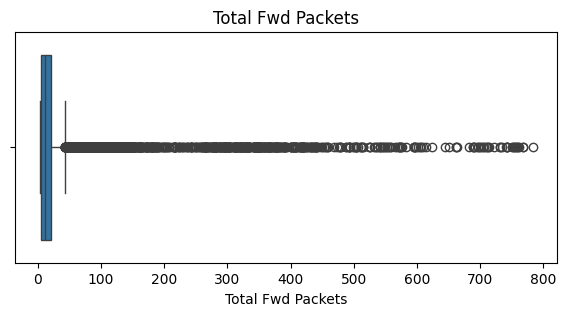

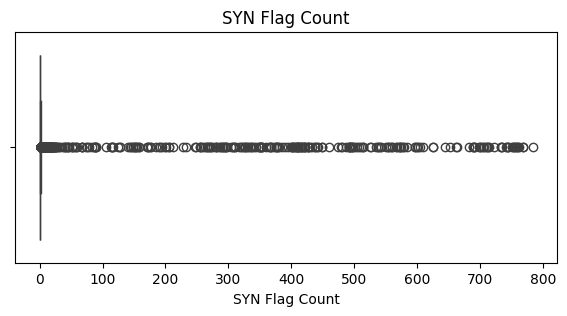

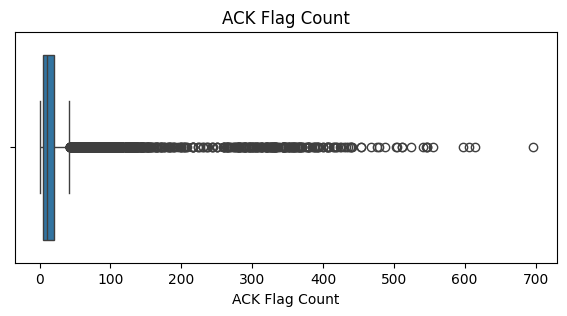

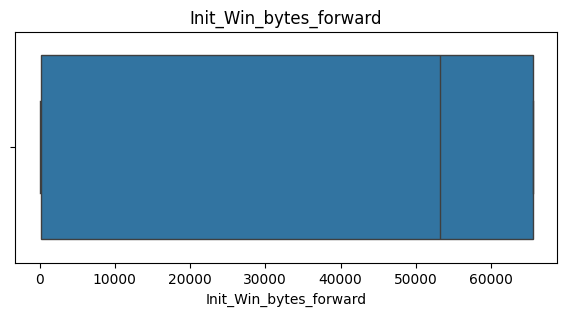

In [11]:
for col in features:

    plt.figure(figsize=(7,3))

    sns.boxplot(
        x=df[col]
    )

    plt.title(col)

    plt.show()

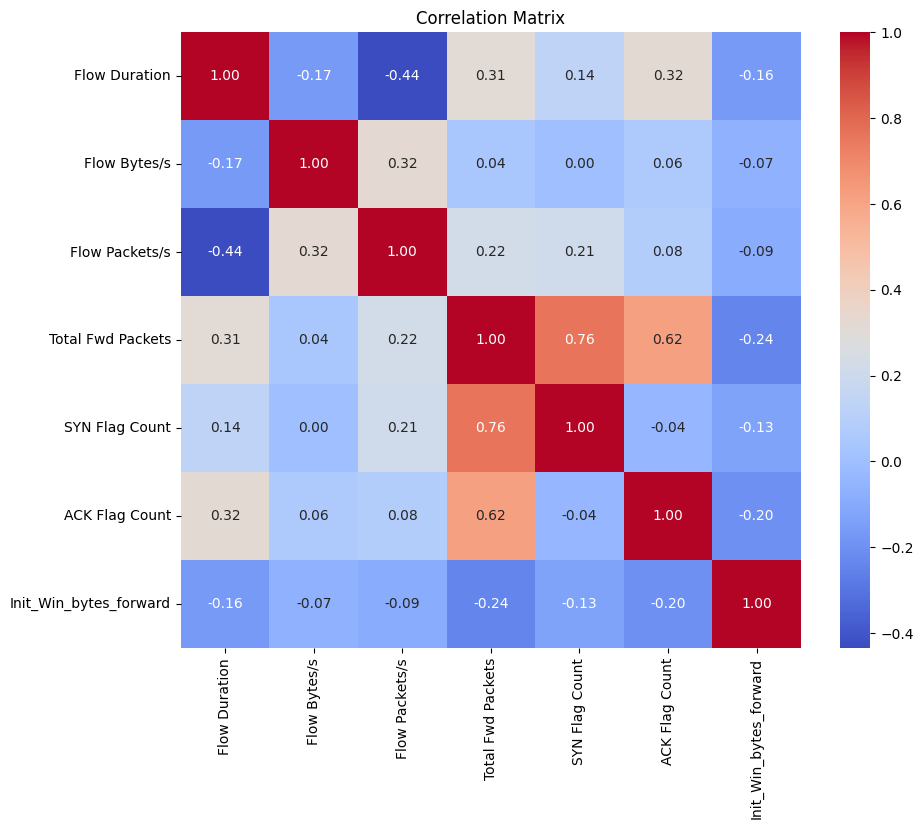

In [12]:
corr = df[features].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

In [13]:
threshold = 0.90

for i in range(len(features)):

    for j in range(i+1,len(features)):

        if abs(corr.iloc[i,j]) > threshold:

            print(
                features[i],
                "<->",
                features[j],
                corr.iloc[i,j]
            )

In [14]:
for col in features:

    counts = df[col].value_counts()

    e = entropy(counts)

    print(f"{col:25s} {e:.4f}")

Flow Duration             9.3698
Flow Bytes/s              9.3708
Flow Packets/s            9.3706
Total Fwd Packets         3.8389
SYN Flag Count            1.1692
ACK Flag Count            3.7568
Init_Win_bytes_forward    2.5533


In [15]:
for col in features:

    print(
        f"{col:25s}",
        df[col].nunique()
    )

Flow Duration             11732
Flow Bytes/s              11741
Flow Packets/s            11739
Total Fwd Packets         454
SYN Flag Count            238
ACK Flag Count            329
Init_Win_bytes_forward    325


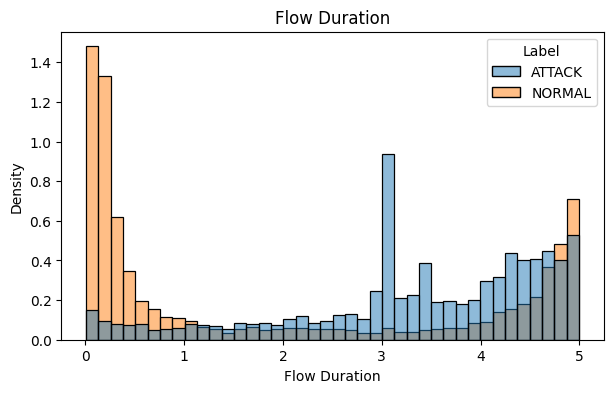

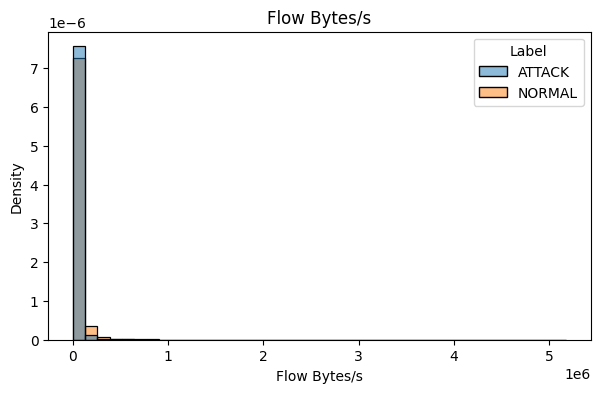

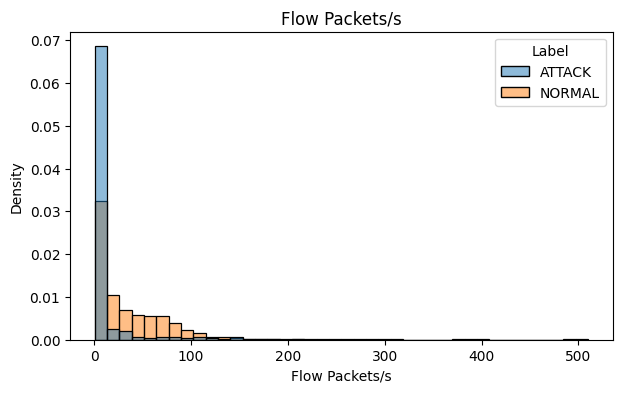

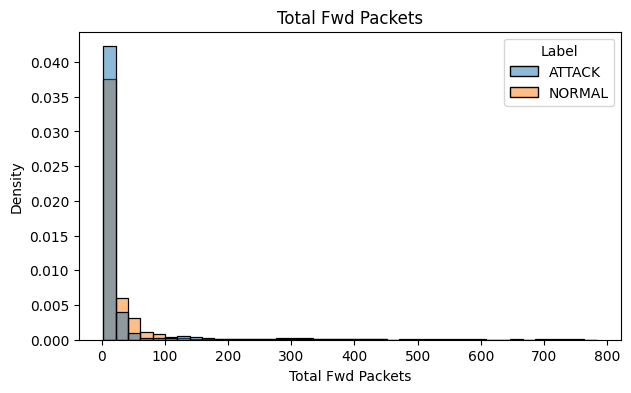

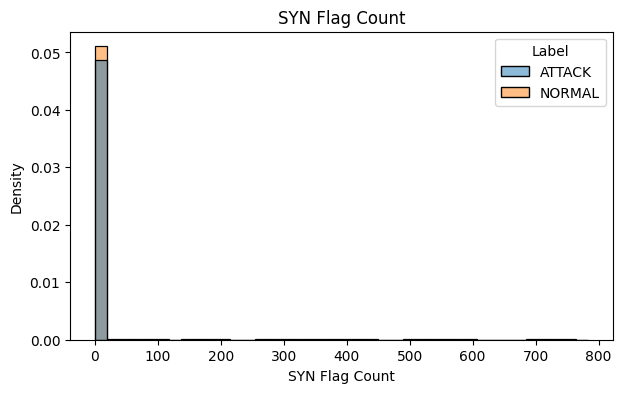

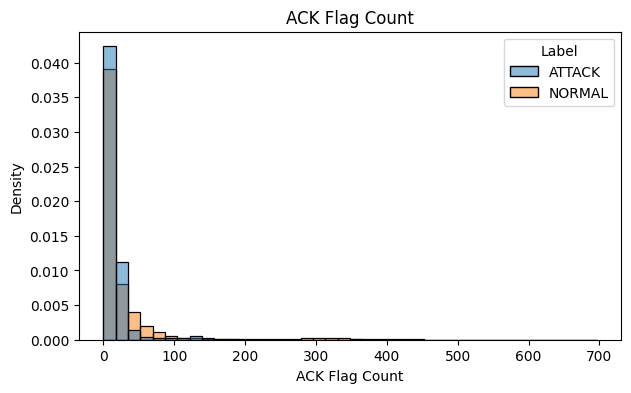

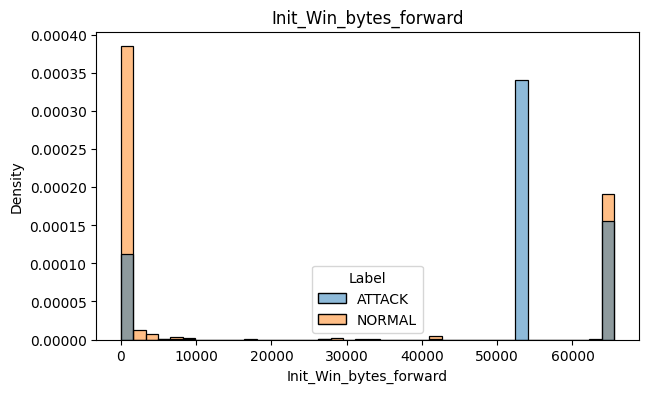

In [16]:
for col in features:

    plt.figure(figsize=(7,4))

    sns.histplot(
        data=df,
        x=col,
        hue="Label",
        bins=40,
        stat="density",
        common_norm=False,
        alpha=0.5
    )

    plt.title(col)

    plt.show()

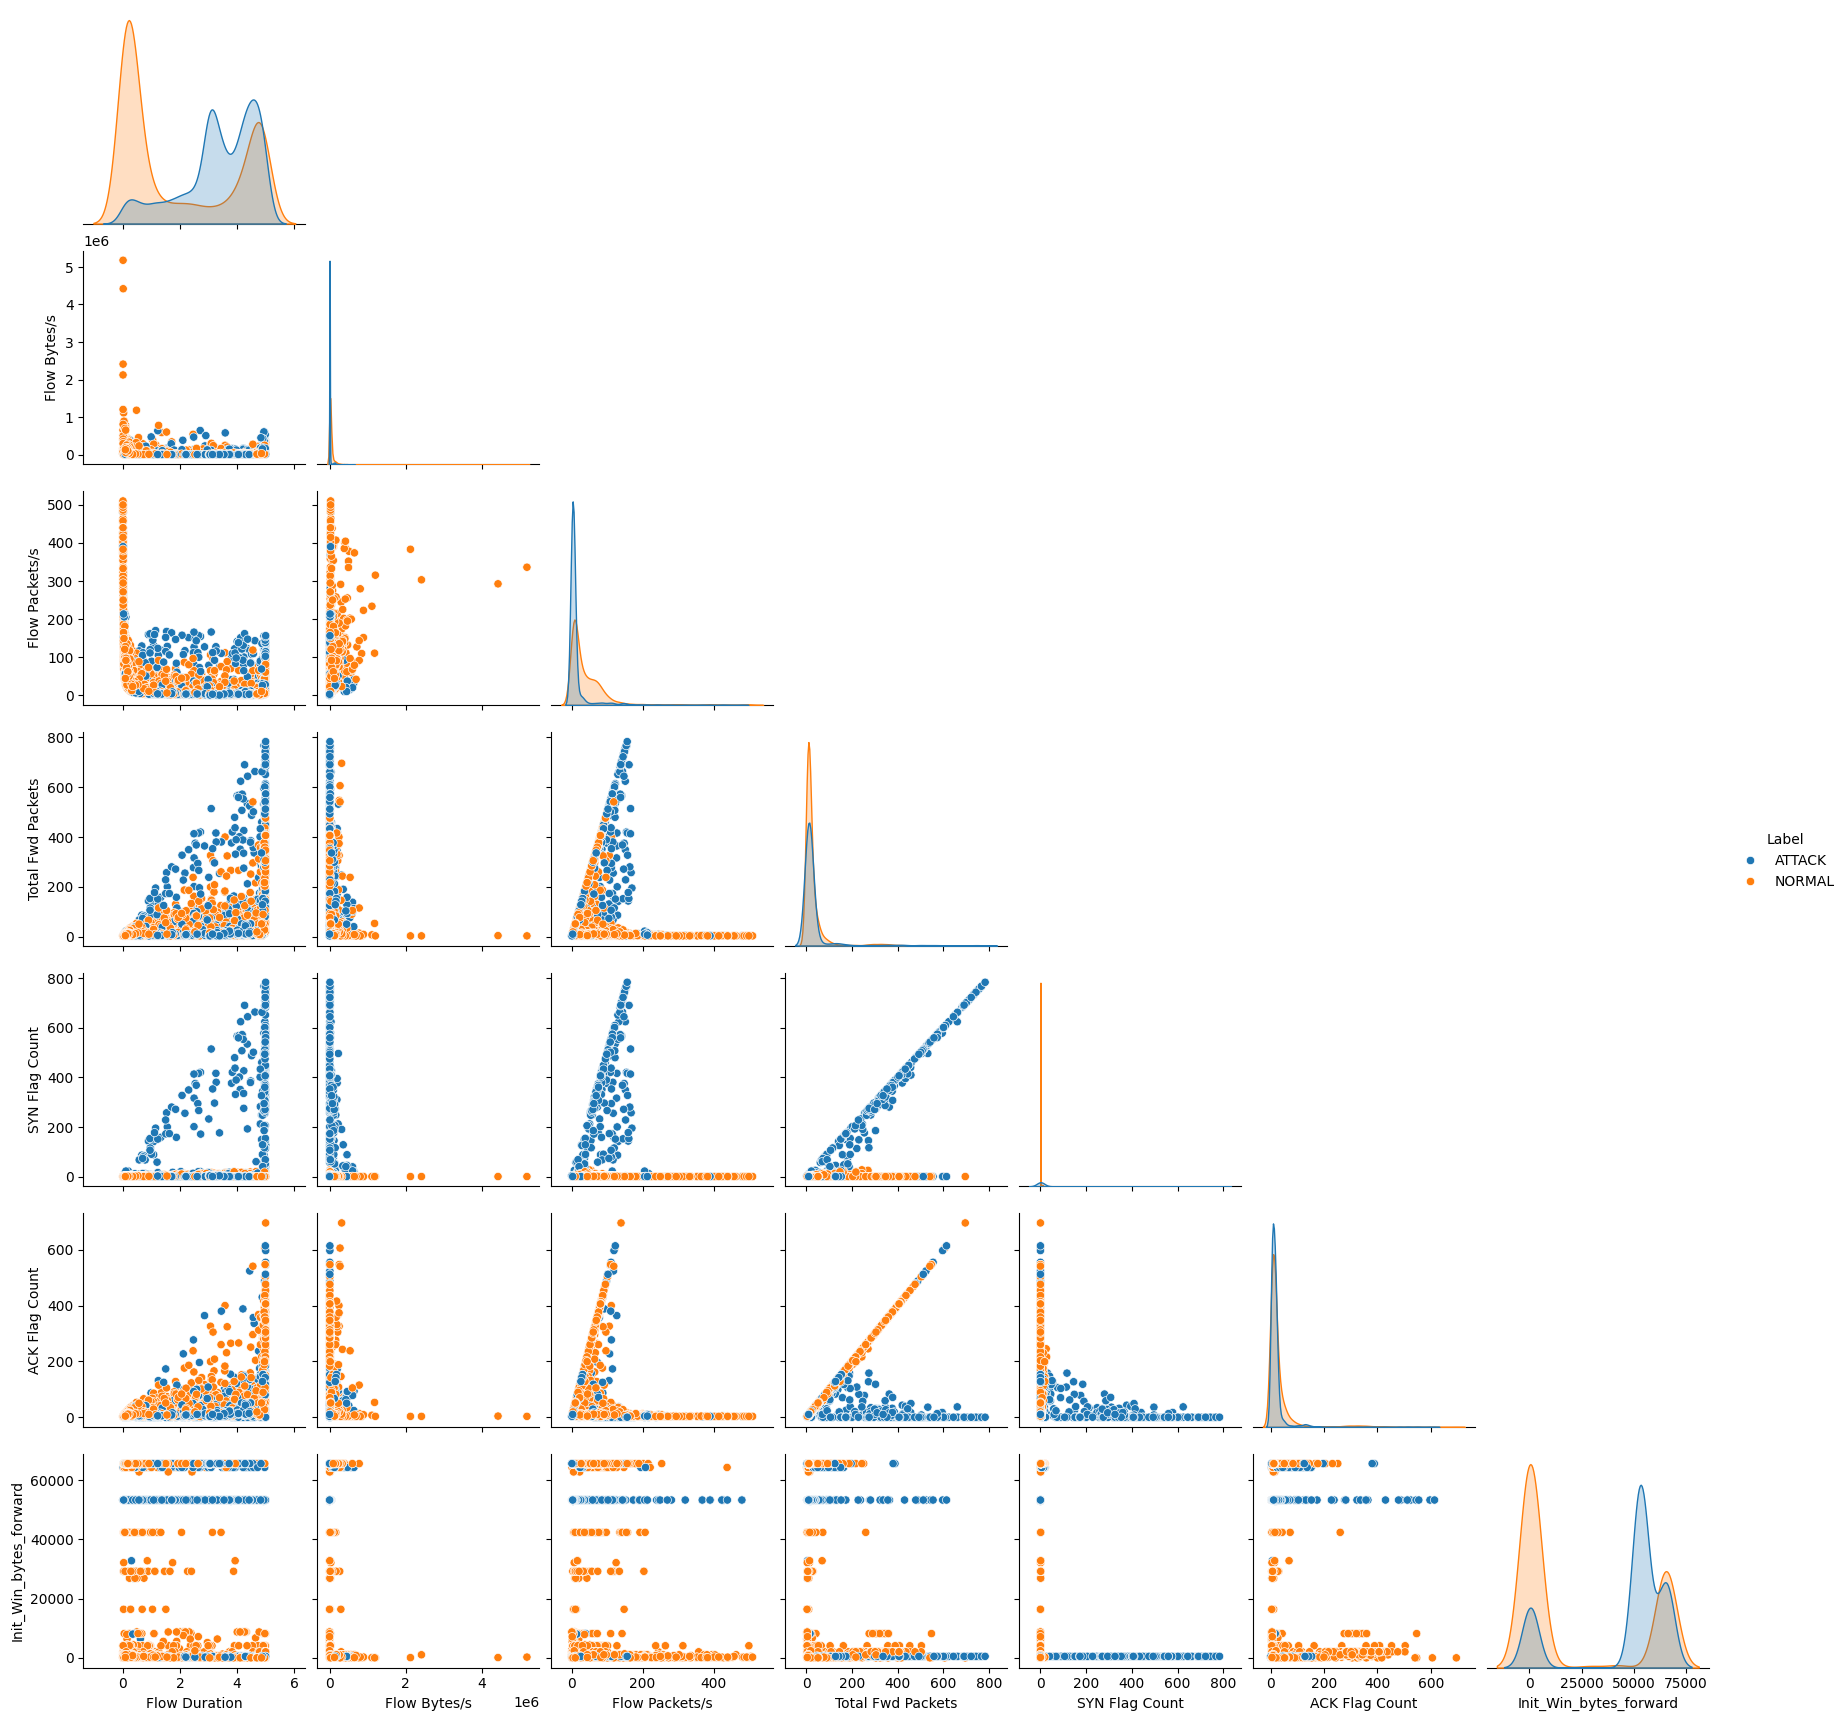

In [17]:
sns.pairplot(
    df,
    hue="Label",
    corner=True
)

plt.show()

In [18]:
print("="*60)
print("EDA SUMMARY")
print("="*60)

print(f"Rows                 : {len(df)}")
print(f"Columns              : {len(df.columns)}")
print(f"Features             : {len(features)}")
print(f"Missing Values       : {df.isnull().sum().sum()}")
print(f"Duplicate Rows       : {df.duplicated().sum()}")

print("\nClass Distribution")

print(df["Label"].value_counts())

print("\nVariance")

print(df[features].var().sort_values())

print("\nStandard Deviation")

print(df[features].std().sort_values())

EDA SUMMARY
Rows                 : 11741
Columns              : 8
Features             : 7
Missing Values       : 0
Duplicate Rows       : 0

Class Distribution
Label
NORMAL    6436
ATTACK    5305
Name: count, dtype: int64

Variance
Flow Duration             3.455170e+00
Flow Packets/s            2.516774e+03
ACK Flag Count            2.642644e+03
SYN Flag Count            3.936116e+03
Total Fwd Packets         6.331384e+03
Init_Win_bytes_forward    8.859547e+08
Flow Bytes/s              8.213869e+09
dtype: float64

Standard Deviation
Flow Duration                 1.858809
Flow Packets/s               50.167460
ACK Flag Count               51.406652
SYN Flag Count               62.738475
Total Fwd Packets            79.569996
Init_Win_bytes_forward    29764.991334
Flow Bytes/s              90630.400199
dtype: float64
